# 🎓 Complete Machine Learning Pipeline
### Data Cleaning → Visualisation → Feature Engineering → Model Training → Evaluation

---

> **Dataset:** Student Habits & Academic Performance (1,000 students)  
> **Goal:** Predict a student's exam score using their lifestyle habits  
> **Model:** Linear Regression  

---

## 📋 Table of Contents

| Step | Topic |
|------|-------|
| 1 | Import Libraries |
| 2 | Load and Explore Data |
| 3 | Clean the Data |
| 4 | Visualise the Data |
| 5 | What is Scikit-learn? |
| 6 | Encode Categorical Columns |
| 7 | Feature Scaling |
| 8 | Train-Test Split |
| 9 | What is Linear Regression? |
| 10 | Train the Model |
| 11 | Evaluate the Model |
| 12 | Visualise Predictions |
| 13 | Predict New Students |
| 14 | Summary + Exercises |

---
# Step 1 — Import Libraries
---

We import all the libraries we need at the very top. This is the standard first cell in every data science and machine learning notebook.

**Why at the top?** So anyone reading the notebook immediately knows what tools we are using.

In [ ]:
# ── Data Manipulation ────────────────────────────────────────
import pandas as pd        # for loading and cleaning data
import numpy as np         # for math and array operations

# ── Visualisation ─────────────────────────────────────────────
import matplotlib.pyplot as plt   # base charting library
import seaborn as sns             # statistical charts on top of matplotlib

# ── Machine Learning (Scikit-learn) ───────────────────────────
from sklearn.model_selection import train_test_split    # split data
from sklearn.linear_model   import LinearRegression     # our model
from sklearn.metrics        import (mean_absolute_error,
                                    mean_squared_error,
                                    r2_score)            # evaluation
from sklearn.preprocessing  import StandardScaler       # feature scaling

# ── Settings ──────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')   # hide minor warnings
%matplotlib inline                 
sns.set_theme(style='whitegrid', font_scale=1.1)

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


---
# Step 2 — Load and Explore the Data
---

**Two key terms to know before we start:**

- **Feature (X)** = the inputs to the model — everything we know about a student (age, study hours, sleep, etc.)
- **Target (y)** = what we want to predict — the exam score

Our job is to teach the model: *given these features, predict this target.*

In [1]:
# Load the CSV file into a DataFrame
df = pd.read_csv('student_habits_performance.csv')

print(f'Loaded: {df.shape[0]} students, {df.shape[1]} columns')

NameError: name 'pd' is not defined

In [4]:
# See the first 5 rows — get a feel for the data
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [5]:
# Overview: column names, data types, non-null counts
# Look for columns where non-null < 1000 — those have missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-null   str    
 13  

In [6]:
# Statistical summary of all numeric columns
# Look at min/max — any impossible values?
# Look at mean — does it make sense?
df.describe().round(2)

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,20.50,3.55,2.51,1.82,84.13,6.47,3.04,5.44,69.60
std,2.31,1.47,1.17,1.08,9.40,1.23,2.03,2.85,16.89
min,17.00,0.00,0.00,0.00,56.00,3.20,0.00,1.00,18.40
25%,18.75,2.60,1.70,1.00,78.00,5.60,1.00,3.00,58.48
50%,20.00,3.50,2.50,1.80,84.40,6.50,3.00,5.00,70.50
75%,23.00,4.50,3.30,2.52,91.02,7.30,5.00,8.00,81.32
max,24.00,8.30,7.20,5.40,100.00,10.00,6.00,10.00,100.00


In [7]:
# Count missing values in each column
# Zero means no missing — good!
df.isnull().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [8]:
# Check for duplicate rows
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


### 📝 What We Found

| Column | Issue |
|--------|-------|
| `parental_education_level` | 91 missing values (9.1%) |
| All other columns | Complete — zero missing |
| Duplicate rows | None |
| Exam score range | 18.4 to 100 — valid |
| Impossible values | None found |

This is already a clean dataset — we only need to fix the 91 missing values and drop the ID column.

---
# Step 3 — Clean the Data
---

Even though this dataset is mostly clean, we still do three things:
1. Make a working copy — never change the original
2. Fill the 91 missing values
3. Drop the student_id column — it is just an ID, not a useful feature

In [9]:
# Always work on a copy — never modify the original
# If something goes wrong, df still has the original data
df_clean = df.copy()

In [10]:
# Fill missing parental_education_level with 'Unknown'
# We use 'Unknown' instead of dropping rows — we keep all 1000 students
df_clean['parental_education_level'] = df_clean['parental_education_level'].fillna('Unknown')

In [11]:
# Drop student_id — it is just an identifier, not a real feature
# The model would learn nothing useful from 'S1000', 'S1001', etc.
df_clean = df_clean.drop(columns=['student_id'])

In [12]:
# Verify — all missing values should be gone now
print('Missing values remaining:', df_clean.isnull().sum().sum())
print('Shape:', df_clean.shape)

Missing values remaining: 0
Shape: (1000, 15)


---
# Step 4 — Visualise the Data
---

**This step is not optional.** Before building any model, always visualise your data.

Visualisation tells us:
- Which features are most related to exam score (so we know what to expect from the model)
- The shape of distributions (normal? skewed?)
- Any patterns the model should pick up

**Rule:** If you skip visualisation and go straight to training, you are flying blind.

### Chart 1 — Exam Score Distribution
What does the target variable look like? Is it normally distributed or skewed?

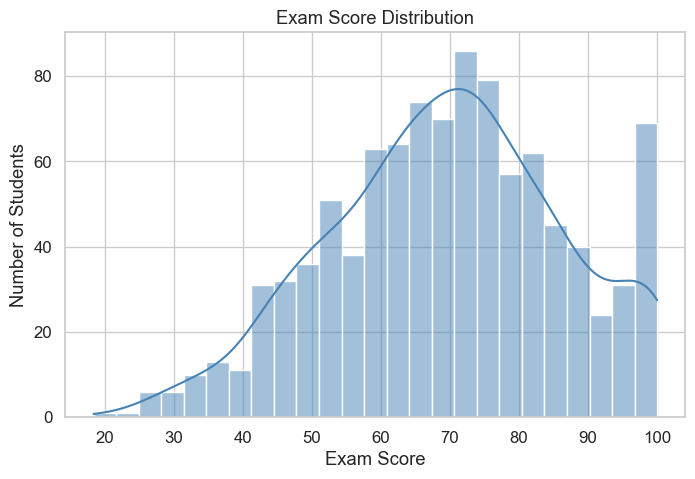

In [13]:
# Histogram of exam score
# kde=True adds a smooth curve showing the overall shape
plt.figure(figsize=(8, 5))
sns.histplot(data=df_clean, x='exam_score', bins=25, kde=True, color='steelblue')
plt.title('Exam Score Distribution')
plt.xlabel('Exam Score')
plt.ylabel('Number of Students')
plt.show()

### Chart 2 — The Most Important Relationship
Study hours vs exam score — this is what we are predicting. Let's see how strong the relationship is visually.

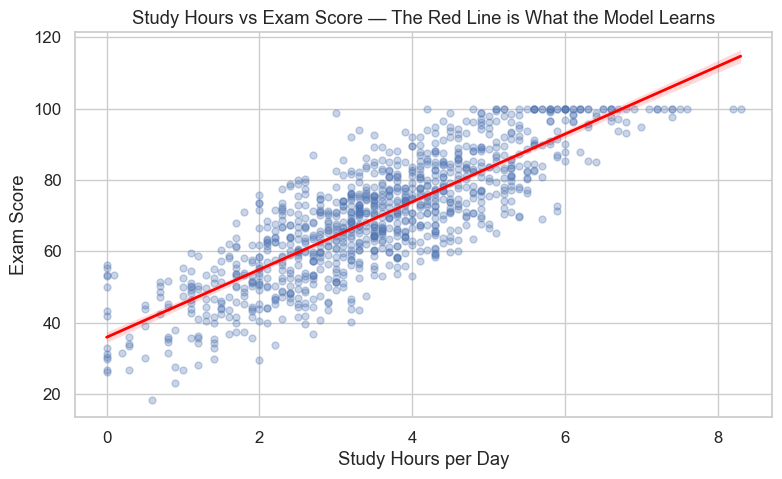

In [14]:
# Scatter plot with trend line — the core relationship
# regplot draws both the scatter dots and the best-fit line
plt.figure(figsize=(9, 5))
sns.regplot(data=df_clean, x='study_hours_per_day', y='exam_score',
            scatter_kws={'alpha': 0.3, 's': 25},
            line_kws={'color': 'red', 'linewidth': 2})
plt.title('Study Hours vs Exam Score — The Red Line is What the Model Learns')
plt.xlabel('Study Hours per Day')
plt.ylabel('Exam Score')
plt.show()

### Chart 3 — Correlation Heatmap
Which features are most related to exam score? The heatmap shows all relationships at once.

**Look at the exam_score row** — the greenest cell tells you the most useful feature for prediction.

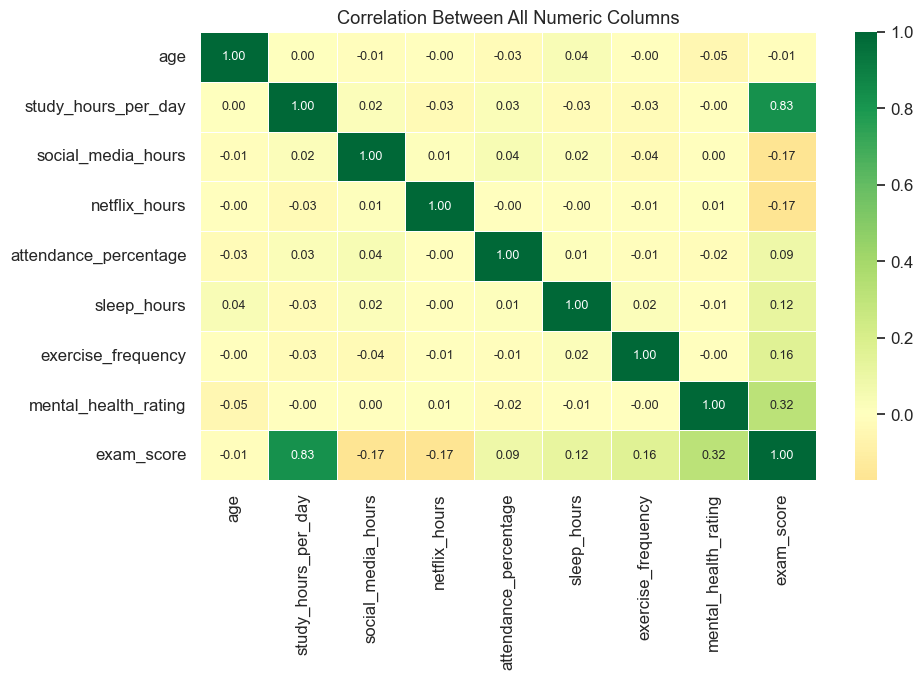

In [15]:
# Correlation heatmap
# corr() calculates how strongly each column relates to every other column
# Values range from -1 (opposite) to +1 (same direction)
plt.figure(figsize=(10, 7))
numeric_cols = df_clean.select_dtypes(include='number').columns
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Between All Numeric Columns')
plt.tight_layout()
plt.show()

### Chart 4 — Box Plots by Category
How does exam score vary by different groups? This tells us which categorical features might be useful.

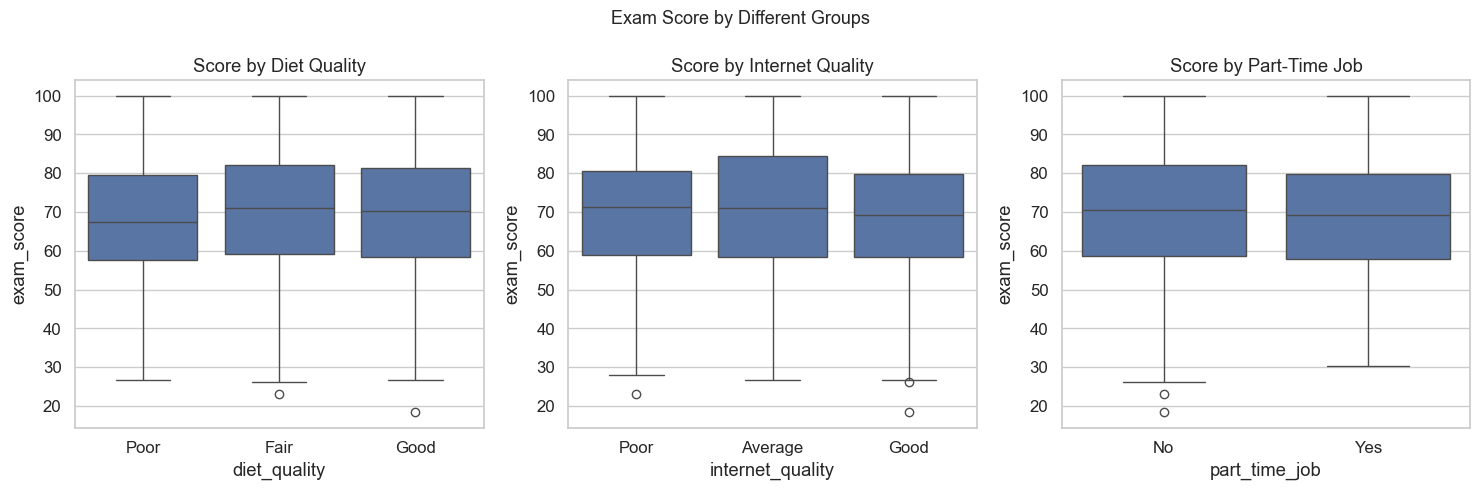

In [16]:
# Box plots — exam score by 3 different categorical features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df_clean, x='diet_quality',   y='exam_score', order=['Poor','Fair','Good'], ax=axes[0])
sns.boxplot(data=df_clean, x='internet_quality', y='exam_score', order=['Poor','Average','Good'], ax=axes[1])
sns.boxplot(data=df_clean, x='part_time_job',  y='exam_score', ax=axes[2])

axes[0].set_title('Score by Diet Quality')
axes[1].set_title('Score by Internet Quality')
axes[2].set_title('Score by Part-Time Job')

plt.suptitle('Exam Score by Different Groups', fontsize=13)
plt.tight_layout()
plt.show()

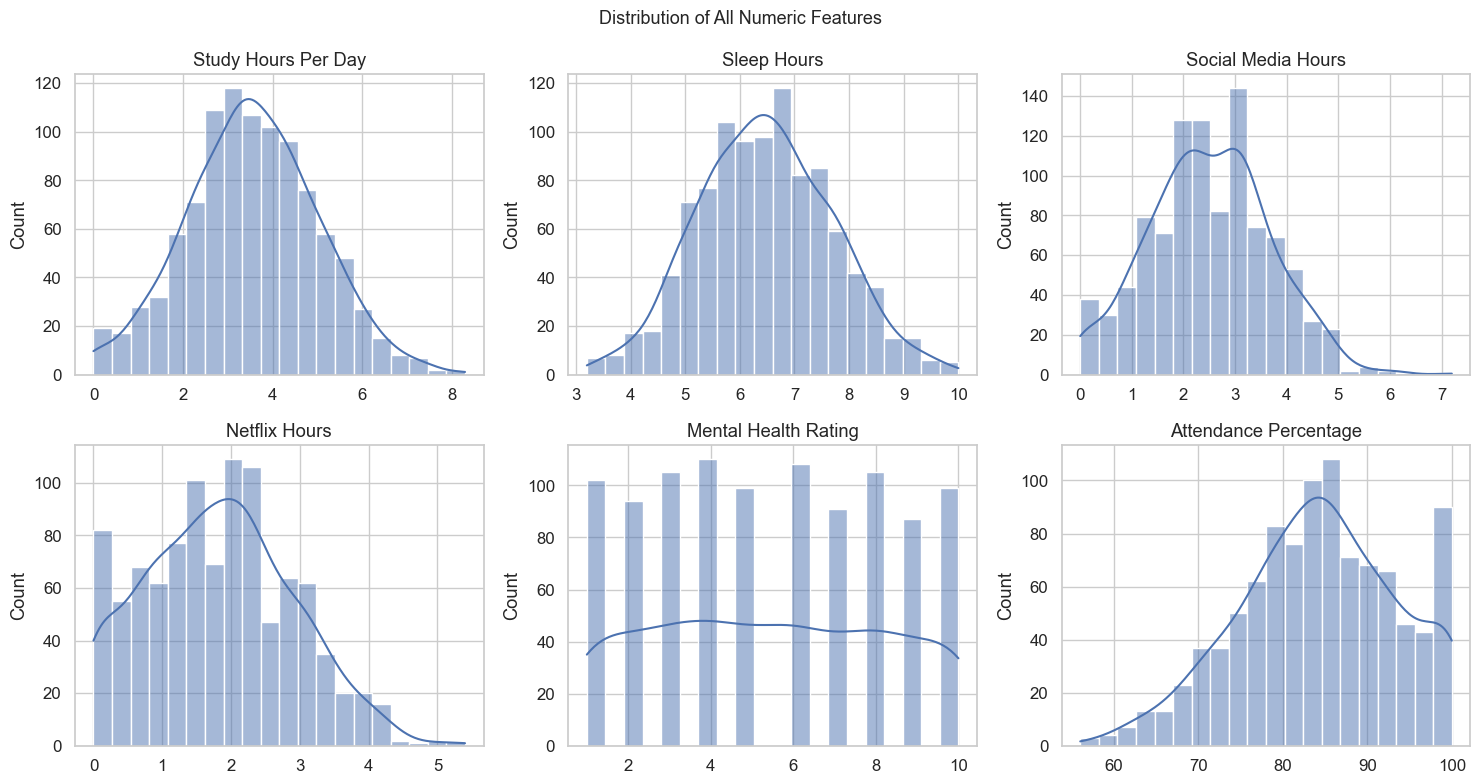

In [17]:
# Distribution of all numeric features
# This helps us understand what range of values each feature has
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features = ['study_hours_per_day','sleep_hours','social_media_hours',
            'netflix_hours','mental_health_rating','attendance_percentage']

for i, col in enumerate(features):
    row, c = divmod(i, 3)
    sns.histplot(data=df_clean, x=col, bins=20, kde=True, ax=axes[row][c])
    axes[row][c].set_title(col.replace('_',' ').title())
    axes[row][c].set_xlabel('')

plt.suptitle('Distribution of All Numeric Features', fontsize=13)
plt.tight_layout()
plt.show()

---
# Step 5 — What is Scikit-learn?
---

## The Most Important ML Library in Python

**Scikit-learn** (imported as `sklearn`) is a free Python library that contains ready-to-use machine learning algorithms.

It was created in **2007** by David Cournapeau as a Google Summer of Code project and is now the world standard for ML.

---

## Why Do We Need It?

Without Scikit-learn, building a Linear Regression model requires writing pages of complex mathematics.

**Without Scikit-learn:**
```python
# Pages of matrix math...
X_b = np.c_[np.ones((len(X), 1)), X]
theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
# ... many more lines
```

**With Scikit-learn:**
```python
model = LinearRegression()    # create
model.fit(X_train, y_train)   # train
model.predict(X_test)         # predict
# Done in 3 lines!
```

---

## The Universal Scikit-learn Pattern

Every single model in Scikit-learn — whether Linear Regression, Random Forest, SVM, or KNN — always follows the **exact same 3 steps**:

```
Step 1:  model = ModelName()          ← Create
Step 2:  model.fit(X_train, y_train)  ← Train (learn)
Step 3:  model.predict(X_test)        ← Predict
```

Learn this pattern once. It works for every model you will ever use.

---

## What Scikit-learn Contains

| Category | Examples |
|----------|----------|
| **Regression** | LinearRegression, Ridge, Lasso, RandomForestRegressor |
| **Classification** | LogisticRegression, DecisionTree, RandomForest, SVM, KNN |
| **Clustering** | KMeans, DBSCAN |
| **Preprocessing** | StandardScaler, LabelEncoder, OneHotEncoder |
| **Model Selection** | train_test_split, cross_val_score, GridSearchCV |
| **Metrics** | accuracy_score, r2_score, mean_absolute_error |

---

## Scikit-learn in AI

- Build and test ML models before moving to deep learning
- Preprocess data for neural networks
- Evaluate model performance
- Select the best features
- Compare multiple algorithms easily

---
# Step 6 — Encode Categorical Columns
---

## Why Encoding Is Necessary

Machine learning models are **pure mathematics**. They only understand numbers. They cannot process words like `'Male'`, `'Good'`, or `'Yes'`.

We must convert every text column into numbers before training. This is called **encoding**.

## One-Hot Encoding — The Standard Method

One-hot encoding creates a new binary (0 or 1) column for each unique category value.

**Example — gender column:**
```
Before:         After one-hot encoding:
gender          gender_Male    gender_Other
Female    →     0              0
Male      →     1              0
Other     →     0              1
Female    →     0              0
```

Why `drop_first=True`? Because if gender is not Male and not Other, it MUST be Female. We do not need a Female column — it is redundant. This avoids the **dummy variable trap**.

In [18]:
# Make a copy for ML preparation
df_ml = df_clean.copy()

# Find which columns are still text (object dtype)
text_cols = df_ml.select_dtypes(include='object').columns.tolist()

print('Columns that need encoding:', text_cols)

Columns that need encoding: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


In [19]:
# One-hot encode all text columns using pandas
# drop_first=True removes the first dummy column per group (avoids redundancy)

df_ml = pd.get_dummies(df_ml, columns=text_cols, drop_first=True)

print(f'Columns before encoding : {len(df_clean.columns)}')
print(f'Columns after encoding  : {len(df_ml.columns)}')
print(f'New shape               : {df_ml.shape}')

Columns before encoding : 15
Columns after encoding  : 20
New shape               : (1000, 20)


In [20]:
# See the new column names after encoding
# Notice: 'gender' is gone, replaced by 'gender_Male' and 'gender_Other'
print('All columns after encoding:')
print(df_ml.columns.tolist())

All columns after encoding:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score', 'gender_Male', 'gender_Other', 'part_time_job_Yes', 'diet_quality_Good', 'diet_quality_Poor', 'parental_education_level_High School', 'parental_education_level_Master', 'parental_education_level_Unknown', 'internet_quality_Good', 'internet_quality_Poor', 'extracurricular_participation_Yes']


In [21]:
# Preview encoded data — all values are now numbers
df_ml.head(3)

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score,gender_Male,gender_Other,part_time_job_Yes,diet_quality_Good,diet_quality_Poor,parental_education_level_High School,parental_education_level_Master,parental_education_level_Unknown,internet_quality_Good,internet_quality_Poor,extracurricular_participation_Yes
0,23,0.0,1.2,1.1,85.0,8.0,6,8,56.2,False,False,False,False,False,False,True,False,False,False,True
1,20,6.9,2.8,2.3,97.3,4.6,6,8,100.0,False,False,False,True,False,True,False,False,False,False,False
2,21,1.4,3.1,1.3,94.8,8.0,1,1,34.3,True,False,False,False,True,True,False,False,False,True,False


### Separate Features (X) and Target (y)

This is a fundamental step in every ML workflow:

- **X (features)** = everything the model uses as INPUT — all columns except exam_score
- **y (target)** = what the model predicts as OUTPUT — the exam_score column

Think of X as the question paper and y as the answer key.

In [22]:
# X = all features (all columns EXCEPT the target)
X = df_ml.drop(columns=['exam_score'])

# y = target (the column we want to predict)
y = df_ml['exam_score']

# Clip y to 0-100 range — prevents model predicting above 100
y = y.clip(0, 100)

print(f'X (features) shape : {X.shape}  → {X.shape[1]} features for each student')
print(f'y (target)   shape : {y.shape}  → one score per student')

X (features) shape : (1000, 19)  → 19 features for each student
y (target)   shape : (1000,)  → one score per student


---
# Step 7 — Feature Scaling
---

## Why Scale Features?

Different columns have very different value ranges:

```
age                   →  17  to  24      (range of 7)
attendance_percentage →  56  to  100     (range of 44)
study_hours_per_day   →  0   to  8.3     (range of 8.3)
mental_health_rating  →  1   to  10      (range of 9)
```

Without scaling, the model might think attendance (0-100) is more important than study hours (0-8) just because its numbers are bigger — even if study hours is actually more informative.

**StandardScaler** solves this by converting every column so it has:
- Mean = 0
- Standard Deviation = 1

After scaling, all columns are on the same level. The model judges them fairly.

## IMPORTANT: Split BEFORE Scaling

We split data first, then scale. Why?
- The scaler must learn statistics (mean, std) from TRAINING data only
- If we scale on all data first, test data leaks into training — **data leakage**
- `fit_transform` on training = learn + apply
- `transform` on test = apply only (no learning from test data)

---
# Step 8 — Train-Test Split
---

## Why Do We Split the Data?

Imagine you are a teacher. You give students 1000 practice problems. On exam day, you give them **new problems they have never seen**.

Machine learning works the same way:
- **Training data (80%)** = practice problems — the model learns from these
- **Test data (20%)** = exam problems — we check performance on these

If we test on the same data we trained on, we would not know if the model truly learned or just memorised. The test set must stay completely separate until evaluation.

```
1000 students
     ↓
train_test_split(test_size=0.2)
     ↓
Training: 800 students → model learns
Test:     200 students → we evaluate
```

In [23]:
# Split FIRST — before any scaling
# test_size=0.2 means 20% goes to test, 80% to training
# random_state=42 makes the split identical every time you run the notebook

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'Total  : {len(X)}')
print(f'Train  : {len(X_train)}  (80%)')
print(f'Test   : {len(X_test)}   (20%)')

Total  : 1000
Train  : 800  (80%)
Test   : 200   (20%)


In [24]:
# Now scale — AFTER splitting
scaler = StandardScaler()

# fit_transform on TRAINING data: learn mean/std from training, then apply
X_train_scaled = scaler.fit_transform(X_train)

# transform on TEST data: apply the SAME mean/std learned from training
# We do NOT call fit_transform on test — that would cause data leakage!

X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print('Scaling done!')
print(f'study_hours mean after scaling: {X_train_scaled["study_hours_per_day"].mean():.4f}  (should be ~0.0)')
print(f'study_hours std  after scaling: {X_train_scaled["study_hours_per_day"].std():.4f}   (should be ~1.0)')

Scaling done!
study_hours mean after scaling: -0.0000  (should be ~0.0)
study_hours std  after scaling: 1.0006   (should be ~1.0)


---
# Step 9 — What is Linear Regression?
---

## The Concept

Linear Regression finds the **best straight line** through data points that predicts the target value.

You already saw this line in the scatter plot — the red trend line. That line IS Linear Regression.

## The Equation

```
exam_score = (w1 × study_hours)
           + (w2 × sleep_hours)
           + (w3 × social_media_hours)
           + (w4 × mental_health_rating)
           + ... (one weight per feature)
           + b   (bias/intercept)
```

- **w1, w2, w3...** = weights — how much each feature contributes
- **b** = bias — the baseline score when all features are zero
- The model **learns** the best values for all weights from training data

## When to Use Linear Regression

✅ Use when:
- Your target is a **continuous number** (score, price, temperature, salary)
- You suspect a **linear relationship** between features and target
- You want a **simple, interpretable** model

❌ Do NOT use when:
- Your target is a category (pass/fail, spam/not spam) — use Logistic Regression
- The relationship is highly non-linear (use Random Forest or Neural Networks)

## In AI
- Predicting house prices from size and location
- Predicting student exam scores from study habits
- Predicting sales from advertising budget
- Predicting hospital patient stay duration

---
# Step 10 — Train the Model
---

Three lines. That is all it takes. Remember the Scikit-learn pattern:
1. Create
2. Train (.fit)
3. Predict

In [25]:
# Step 1 — Create the model object
# At this point the model is empty — it has not seen any data yet
model = LinearRegression()
print('Model created — not trained yet')

Model created — not trained yet


In [26]:
# Step 2 — Train the model
# .fit() is where ALL the learning happens
# The model reads X_train and y_train and finds the best weights
# This is the most important line in machine learning

model.fit(X_train_scaled, y_train)

print('✅ Model trained!')

✅ Model trained!


In [27]:
# Step 3 — Make predictions on the TEST set
# These are 200 students the model has NEVER seen before
y_pred = model.predict(X_test_scaled)

# Clip predictions to valid range — linear regression can predict above 100
y_pred = np.clip(y_pred, 0, 100)

print('✅ Predictions made!')
print(f'\nFirst 5 actual scores    : {y_test.values[:5].round(1)}')
print(f'First 5 predicted scores : {y_pred[:5].round(1)}')

✅ Predictions made!

First 5 actual scores    : [64.2 72.7 79.  79.5 58.2]
First 5 predicted scores : [66.3 75.2 77.8 73.4 61.1]
